In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
data1 = pd.read_csv("/content/realtor-data.zip_part001.csv")
data2 = pd.read_csv("/content/realtor-data.zip_part002.csv")
data3 = pd.read_csv("/content/realtor-data.zip_part003.csv")
data4 = pd.read_csv("/content/realtor-data.zip_part004.csv")

In [10]:
merged_df1= pd.merge(data1, data2, how='outer')
merged_df2 = pd.merge(data3, data4, how='outer')
data = pd.merge(merged_df1, merged_df2, how='outer')
data.shape

(2226382, 12)

In [11]:
data.info()
data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   brokered_by     float64
 1   status          object 
 2   price           float64
 3   bed             float64
 4   bath            float64
 5   acre_lot        float64
 6   street          float64
 7   city            object 
 8   state           object 
 9   zip_code        float64
 10  house_size      float64
 11  prev_sold_date  object 
dtypes: float64(8), object(4)
memory usage: 203.8+ MB


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,0.0,for_sale,190000.0,NaN,NaN,4.27,77775.0,Savannah,Georgia,31419.0,NaN,NaN
1,0.0,for_sale,265000.0,4.0,3.0,0.22,296128.0,Savannah,Georgia,31419.0,1487.0,2006-07-11
2,0.0,for_sale,279900.0,3.0,2.0,0.20,1623254.0,Savannah,Georgia,31419.0,1728.0,2009-04-06
3,0.0,sold,179900.0,3.0,2.0,0.20,93274.0,Rincon,Georgia,31326.0,1100.0,2021-12-03
4,0.0,sold,205000.0,2.0,2.0,0.03,458694.0,Savannah,Georgia,31419.0,1040.0,2022-02-09
...,...,...,...,...,...,...,...,...,...,...,...,...
2226377,NaN,sold,9950000.0,5.0,7.0,NaN,75414.0,Bonita Springs,Florida,34134.0,4865.0,2022-04-07
2226378,NaN,sold,10995000.0,6.0,7.0,0.46,807141.0,Santa Monica,California,90402.0,5351.0,2021-11-10
2226379,NaN,sold,14950000.0,3.0,6.0,0.41,1763512.0,Los Angeles,California,90069.0,5911.0,2022-04-15
2226380,NaN,sold,24995000.0,5.0,8.0,0.98,140034.0,Beverly Hills,California,90210.0,7500.0,2022-03-17


In [12]:
data.dropna(inplace=True)

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1084909 entries, 1 to 2221848
Data columns (total 12 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   brokered_by     1084909 non-null  float64
 1   status          1084909 non-null  object 
 2   price           1084909 non-null  float64
 3   bed             1084909 non-null  float64
 4   bath            1084909 non-null  float64
 5   acre_lot        1084909 non-null  float64
 6   street          1084909 non-null  float64
 7   city            1084909 non-null  object 
 8   state           1084909 non-null  object 
 9   zip_code        1084909 non-null  float64
 10  house_size      1084909 non-null  float64
 11  prev_sold_date  1084909 non-null  object 
dtypes: float64(8), object(4)
memory usage: 107.6+ MB


In [14]:
from sklearn.model_selection import train_test_split

X = data.drop(['price', 'brokered_by'], axis=1)
y = data['price']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [16]:
train_data = X_train.join(y_train)
train_data

,status,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date,price
2197736,for_sale,4.0,4.0,0.24,1780829.0,Big Timber,Montana,59011.0,2364.0,2016-09-29,475000.0
1617426,sold,3.0,3.0,0.04,854641.0,Ankeny,Iowa,50023.0,1570.0,2022-04-18,222500.0
180970,sold,2.0,2.0,4.68,1673955.0,Cottage Grove,Oregon,97424.0,1671.0,2022-01-25,550000.0
1011974,for_sale,3.0,3.0,2.77,1176896.0,Grants Pass,Oregon,97527.0,3304.0,1998-12-15,1250000.0
1612206,sold,3.0,2.0,0.19,227342.0,Colton,California,92324.0,1435.0,2022-03-23,465000.0
...,...,...,...,...,...,...,...,...,...,...,...
1565051,sold,2.0,2.0,0.15,1798926.0,Fort Myers,Florida,33908.0,1652.0,2022-03-30,459000.0
1483935,for_sale,3.0,2.0,0.48,1826739.0,Dallas,Georgia,30132.0,1829.0,2009-09-03,360000.0
1166949,sold,3.0,2.0,0.56,1207619.0,Sherman,Texas,75090.0,1568.0,2022-04-29,165000.0
713585,for_sale,3.0,2.0,0.19,968437.0,El Paso,Texas,79930.0,2043.0,2015-08-11,110000.0


In [17]:
train_data.corr(numeric_only=True)

,bed,bath,acre_lot,street,zip_code,house_size,price
bed,1.000000,0.686911,-0.001083,-0.002856,-0.036433,0.224230,0.197560
bath,0.686911,1.000000,-0.001687,-0.001422,-0.013022,0.303739,0.367799
acre_lot,-0.001083,-0.001687,1.000000,0.001848,-0.006032,-0.000188,0.001003
street,-0.002856,-0.001422,0.001848,1.000000,0.003202,0.000478,0.002642
zip_code,-0.036433,-0.013022,-0.006032,0.003202,1.000000,-0.009151,0.090633
house_size,0.224230,0.303739,-0.000188,0.000478,-0.009151,1.000000,0.174059
price,0.197560,0.367799,0.001003,0.002642,0.090633,0.174059,1.000000


array([[<Axes: title={'center': 'bed'}>,
        <Axes: title={'center': 'bath'}>,
        <Axes: title={'center': 'acre_lot'}>],
       [<Axes: title={'center': 'street'}>,
        <Axes: title={'center': 'zip_code'}>,
        <Axes: title={'center': 'house_size'}>],
       [<Axes: title={'center': 'price'}>, <Axes: >, <Axes: >]],
      dtype=object)

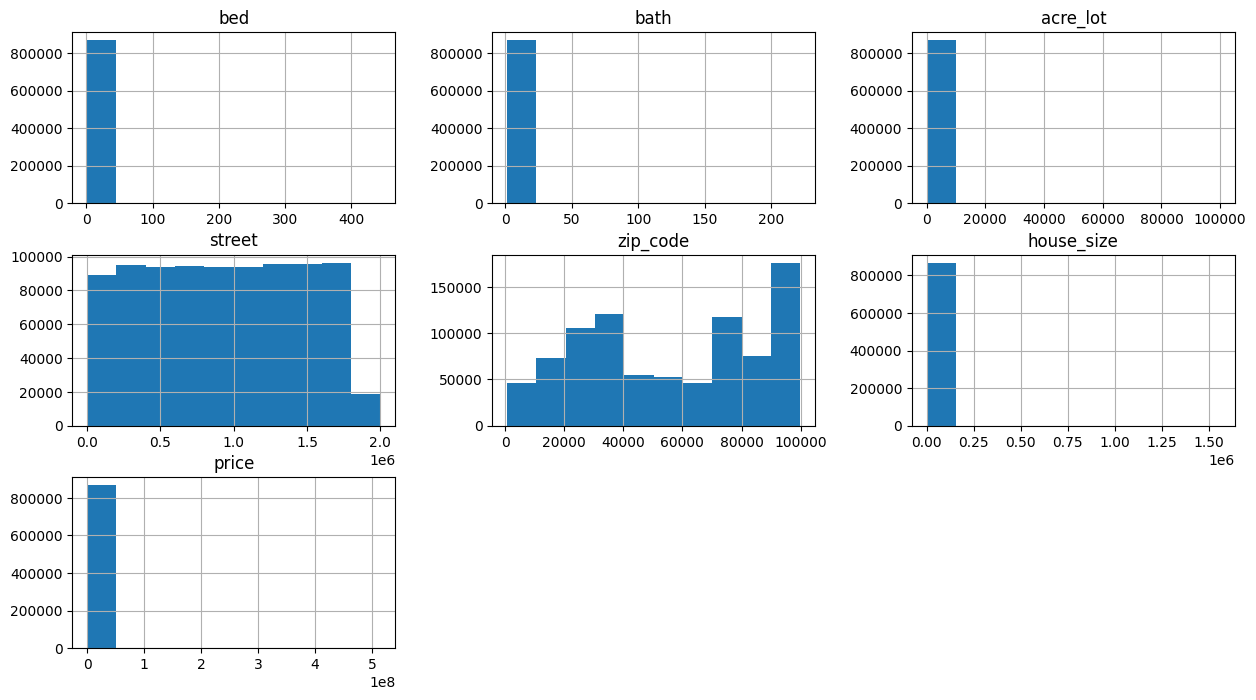

In [18]:
train_data.hist(figsize=(15,8))

<Axes: >

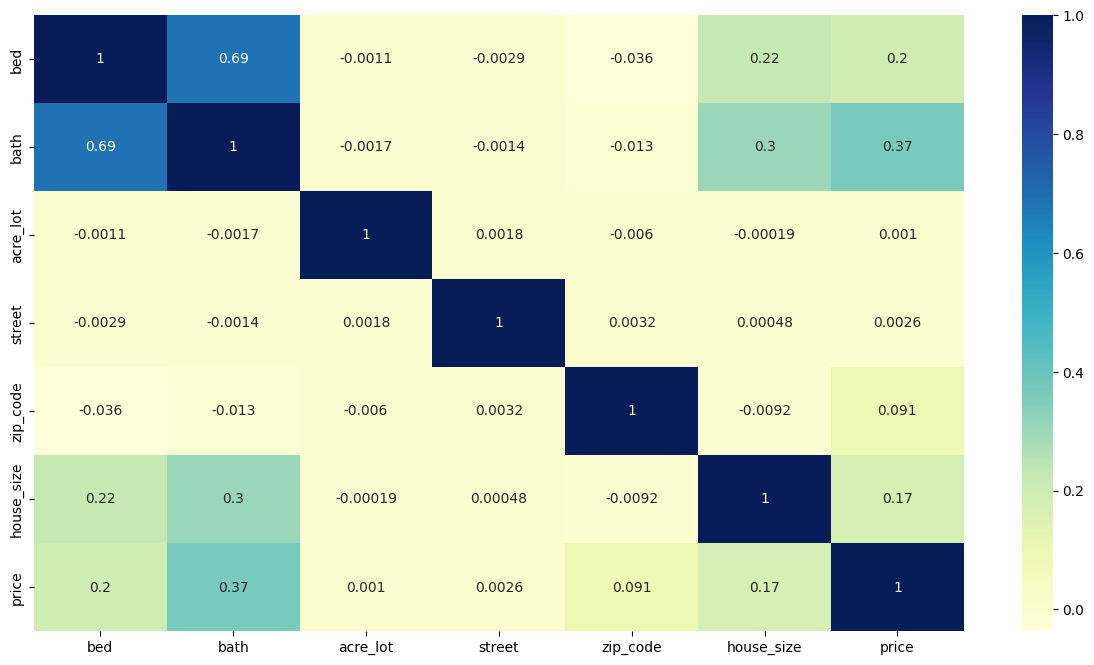

In [19]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True),annot=True, cmap="YlGnBu")

In [20]:
train_data['bed'] = np.log(train_data['bed'] + 1)
train_data['bath'] = np.log(train_data['bath'] + 1)
train_data['house_size'] = np.log(train_data['house_size'] + 1)
train_data['acre_lot'] = np.log(train_data['acre_lot'] + 1)




array([[<Axes: title={'center': 'bed'}>,
        <Axes: title={'center': 'bath'}>,
        <Axes: title={'center': 'acre_lot'}>],
       [<Axes: title={'center': 'street'}>,
        <Axes: title={'center': 'zip_code'}>,
        <Axes: title={'center': 'house_size'}>],
       [<Axes: title={'center': 'price'}>, <Axes: >, <Axes: >]],
      dtype=object)

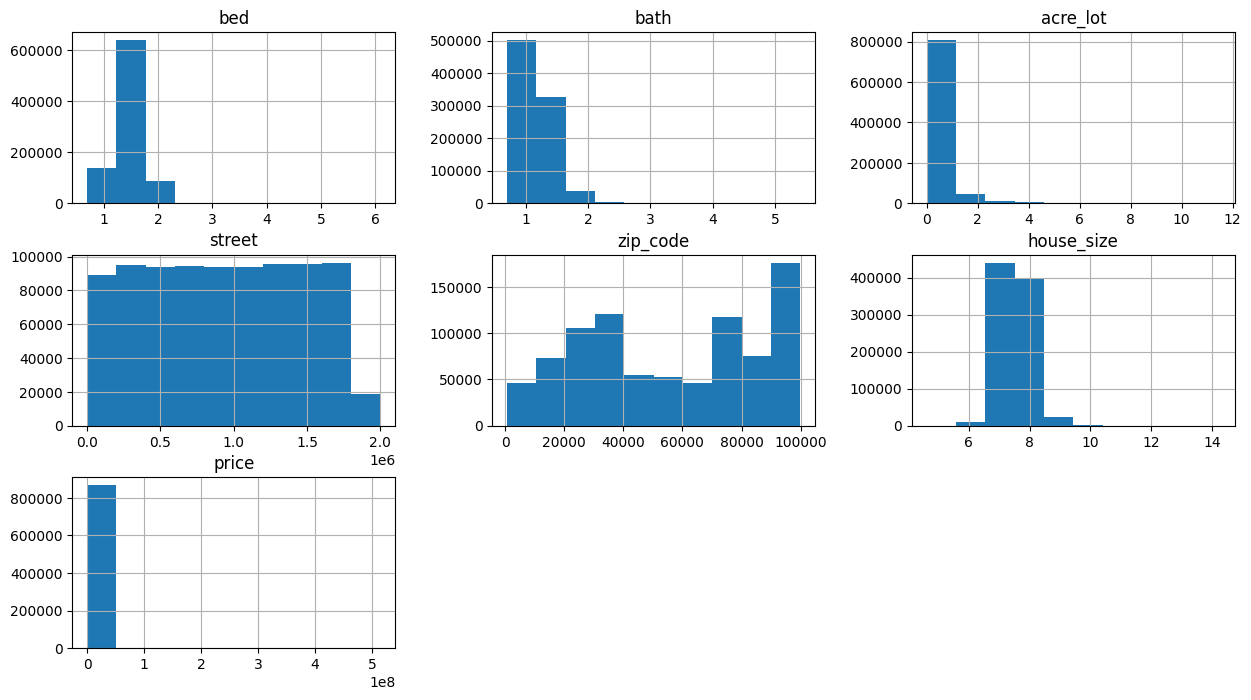

In [21]:
train_data.hist(figsize=(15,8))

In [22]:
train_data = train_data.join(pd.get_dummies(train_data['state'], dtype=int)).drop(['state'], axis=1)


In [23]:
train_data = train_data.drop(['city','status'],axis=1)
train_data

,bed,bath,acre_lot,street,zip_code,house_size,prev_sold_date,price,Alabama,Alaska,...,Tennessee,Texas,Utah,Vermont,Virgin Islands,Virginia,Washington,West Virginia,Wisconsin,Wyoming
2197736,1.609438,1.609438,0.215111,1780829.0,59011.0,7.768533,2016-09-29,475000.0,0,0,...,0,0,0,0,0,0,0,0,0,0
1617426,1.386294,1.386294,0.039221,854641.0,50023.0,7.359468,2022-04-18,222500.0,0,0,...,0,0,0,0,0,0,0,0,0,0
180970,1.098612,1.098612,1.736951,1673955.0,97424.0,7.421776,2022-01-25,550000.0,0,0,...,0,0,0,0,0,0,0,0,0,0
1011974,1.386294,1.386294,1.327075,1176896.0,97527.0,8.103192,1998-12-15,1250000.0,0,0,...,0,0,0,0,0,0,0,0,0,0
1612206,1.386294,1.098612,0.173953,227342.0,92324.0,7.269617,2022-03-23,465000.0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1565051,1.098612,1.098612,0.139762,1798926.0,33908.0,7.410347,2022-03-30,459000.0,0,0,...,0,0,0,0,0,0,0,0,0,0
1483935,1.386294,1.098612,0.392042,1826739.0,30132.0,7.512071,2009-09-03,360000.0,0,0,...,0,0,0,0,0,0,0,0,0,0
1166949,1.386294,1.098612,0.444686,1207619.0,75090.0,7.358194,2022-04-29,165000.0,0,0,...,0,1,0,0,0,0,0,0,0,0
713585,1.386294,1.098612,0.173953,968437.0,79930.0,7.622664,2015-08-11,110000.0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [24]:
train_data["prev_sold_date"] = pd.to_datetime(
    train_data["prev_sold_date"],
    errors="coerce"
)

# Day of week
dow = train_data["prev_sold_date"].dt.dayofweek
train_data["dow_sin"] = np.sin(2 * np.pi * dow / 7)
train_data["dow_cos"] = np.cos(2 * np.pi * dow / 7)

# Day of year
doy = train_data["prev_sold_date"].dt.dayofyear
year_length = np.where(
    train_data["prev_sold_date"].dt.is_leap_year,
    366,
    365
)

train_data["doy_sin"] = np.sin(2 * np.pi * doy / year_length)
train_data["doy_cos"] = np.cos(2 * np.pi * doy / year_length)

# Month
month = train_data["prev_sold_date"].dt.month
train_data["month_sin"] = np.sin(2 * np.pi * month / 12)
train_data["month_cos"] = np.cos(2 * np.pi * month / 12)

# drop the original date column afterward
train_data = train_data.drop(columns=["prev_sold_date"])



In [25]:
train_data = train_data.drop(['street'], axis=1)
train_data

,bed,bath,acre_lot,zip_code,house_size,price,Alabama,Alaska,Arizona,Arkansas,...,Washington,West Virginia,Wisconsin,Wyoming,dow_sin,dow_cos,doy_sin,doy_cos,month_sin,month_cos
2197736,1.609438,1.609438,0.215111,59011.0,7.768533,475000.0,0,0,0,0,...,0,0,0,0,0.433884,-0.900969,-0.999668,-0.025748,-1.000000e+00,-1.836970e-16
1617426,1.386294,1.386294,0.039221,50023.0,7.359468,222500.0,0,0,0,0,...,0,0,0,0,0.000000,1.000000,0.958718,-0.284359,8.660254e-01,-5.000000e-01
180970,1.098612,1.098612,1.736951,97424.0,7.421776,550000.0,0,0,0,0,...,0,0,0,0,0.781831,0.623490,0.417194,0.908818,5.000000e-01,8.660254e-01
1011974,1.386294,1.386294,1.327075,97527.0,8.103192,1250000.0,0,0,0,0,...,0,0,0,0,0.781831,0.623490,-0.271958,0.962309,-2.449294e-16,1.000000e+00
1612206,1.386294,1.098612,0.173953,92324.0,7.269617,465000.0,0,0,0,0,...,0,0,0,0,0.974928,-0.222521,0.987349,0.158559,1.000000e+00,6.123234e-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1565051,1.098612,1.098612,0.139762,33908.0,7.410347,459000.0,0,0,0,0,...,0,0,0,0,0.974928,-0.222521,0.999250,0.038722,1.000000e+00,6.123234e-17
1483935,1.386294,1.098612,0.392042,30132.0,7.512071,360000.0,0,0,0,0,...,0,0,0,0,0.433884,-0.900969,-0.888057,-0.459733,-1.000000e+00,-1.836970e-16
1166949,1.386294,1.098612,0.444686,75090.0,7.358194,165000.0,0,0,0,0,...,0,0,0,0,-0.433884,-0.900969,0.888057,-0.459733,8.660254e-01,-5.000000e-01
713585,1.386294,1.098612,0.173953,79930.0,7.622664,110000.0,0,0,0,0,...,0,0,0,0,0.781831,0.623490,-0.642055,-0.766659,-8.660254e-01,-5.000000e-01


In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train, y_train = train_data.drop(['price'], axis=1), train_data['price']
X_train_s = scaler.fit_transform(X_train)

reg = LinearRegression()

reg.fit(X_train_s, y_train)


LinearRegression()

In [27]:
test_data = X_test.join(y_test)

test_data['bed'] = np.log(test_data['bed'] + 1)
test_data['bath'] = np.log(test_data['bath'] + 1)
test_data['house_size'] = np.log(test_data['house_size'] + 1)
test_data['acre_lot'] = np.log(test_data['acre_lot'] + 1)

test_data = test_data.join(pd.get_dummies(test_data['state'], dtype=int)).drop(['state'], axis=1)
test_data = test_data.drop(['city','status'],axis=1)

test_data["prev_sold_date"] = pd.to_datetime(
    test_data["prev_sold_date"],
    errors="coerce"
)

# Day of week
dow = test_data["prev_sold_date"].dt.dayofweek
test_data["dow_sin"] = np.sin(2 * np.pi * dow / 7)
test_data["dow_cos"] = np.cos(2 * np.pi * dow / 7)

# Day of year
doy = test_data["prev_sold_date"].dt.dayofyear
year_length = np.where(
    test_data["prev_sold_date"].dt.is_leap_year,
    366,
    365
)

test_data["doy_sin"] = np.sin(2 * np.pi * doy / year_length)
test_data["doy_cos"] = np.cos(2 * np.pi * doy / year_length)

# Month
month = test_data["prev_sold_date"].dt.month
test_data["month_sin"] = np.sin(2 * np.pi * month / 12)
test_data["month_cos"] = np.cos(2 * np.pi * month / 12)

# drop the original date column afterward
test_data = test_data.drop(columns=["prev_sold_date"])


In [28]:
test_data = test_data.drop(['street'], axis=1)
X_test, y_test = test_data.drop(['price'], axis=1), test_data['price']


In [29]:
X_test_s = scaler.transform(X_test)

In [30]:
reg.score(X_test_s,y_test)

0.23597301811157245

In [31]:
from sklearn.ensemble import HistGradientBoostingRegressor

model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

HistGradientBoostingRegressor(learning_rate=0.05, max_iter=300, random_state=42)

In [32]:
model.score(X_test, y_test)

0.5774401005202485

In [33]:
from sklearn.preprocessing import StandardScaler

x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.values.reshape(-1, 1)
)

y_test_scaled = y_scaler.transform(
    y_test.values.reshape(-1, 1)
)

In [34]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Convert data
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)
y_train_tensor = torch.tensor(
    y_train_scaled,
    dtype=torch.float32
)
train_ds = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(
    train_ds,
    batch_size=4096,
    shuffle=True
)

class HouseNet(nn.Module):
    def __init__(self, n_features):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(n_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

model = HouseNet(X_train.shape[1])

criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [35]:
epochs = 20

for epoch in range(epochs):
    model.train()

    running_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        preds = model(X_batch)

        loss = criterion(preds, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}: "
        f"{running_loss / len(train_loader):.4f}"
    )

Epoch 1: 0.6954
Epoch 2: 0.6352
Epoch 3: 0.6383
Epoch 4: 0.6161
Epoch 5: 0.6150
Epoch 6: 0.6070
Epoch 7: 0.6095
Epoch 8: 0.6048
Epoch 9: 0.5956
Epoch 10: 0.6022
Epoch 11: 0.5848
Epoch 12: 0.5858
Epoch 13: 0.5908
Epoch 14: 0.5991
Epoch 15: 0.5849
Epoch 16: 0.5864
Epoch 17: 0.5770
Epoch 18: 0.5693
Epoch 19: 0.5781
Epoch 20: 0.5728


In [36]:
from sklearn.metrics import r2_score

model.eval()

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

with torch.no_grad():
    preds_scaled = model(X_test_tensor).numpy()

preds = y_scaler.inverse_transform(preds_scaled)

r2 = r2_score(y_test, preds)

print("Validation R²:", r2)

Validation R²: 0.5084501869868501


In [37]:
import lightgbm as lgb
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.01,
    num_leaves=128,
    subsample=1.0,
    colsample_bytree=1.0,
    reg_alpha=0.0,
    reg_lambda=0.0,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(100)
    ]
)

preds = model.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036872 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1459
[LightGBM] [Info] Number of data points in the train set: 867927, number of used features: 63
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 568573.285200
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[822]	valid_0's rmse: 653595	valid_0's l2: 4.27186e+11


In [38]:
from sklearn.metrics import r2_score

print(r2_score(y_test, preds))
print(model.best_iteration_)

0.5905898549039712
822


In [39]:
!pip install category-encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.0 MB/s eta 0:00:00


In [40]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor
import category_encoders as ce
import lightgbm as lgb

# ----------------------------
# 1. Split data
# ----------------------------
X = data.drop(columns=["price"]).copy()
y = data["price"].copy()

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# 2. Remove unwanted columns
# ----------------------------
drop_cols = ["city", "status"]
X_train = X_train.drop(columns=drop_cols)
X_valid = X_valid.drop(columns=drop_cols)

# ----------------------------
# 3. Handle prev_sold_date (KEEP IT, but convert properly)
# ----------------------------
for df in [X_train, X_valid]:
    df["prev_sold_date"] = pd.to_datetime(df["prev_sold_date"], errors="coerce")

    df["prev_year"] = df["prev_sold_date"].dt.year
    df["prev_month"] = df["prev_sold_date"].dt.month
    df["prev_dayofyear"] = df["prev_sold_date"].dt.dayofyear

    # cyclical encoding (optional but strong)
    df["prev_month_sin"] = np.sin(2 * np.pi * df["prev_month"] / 12)
    df["prev_month_cos"] = np.cos(2 * np.pi * df["prev_month"] / 12)

    df["prev_doy_sin"] = np.sin(2 * np.pi * df["prev_dayofyear"] / 365)
    df["prev_doy_cos"] = np.cos(2 * np.pi * df["prev_dayofyear"] / 365)

    df.drop(columns=["prev_sold_date"], inplace=True)

# ----------------------------
# 4. Log transform target
# ----------------------------
y_train = np.log1p(y_train)
y_valid = np.log1p(y_valid)

# ----------------------------
# 5. Feature engineering
# ----------------------------
def add_features(df):
    df = df.copy()

    df["size_per_bed"] = df["house_size"] / (df["bed"] + 1)
    df["size_per_bath"] = df["house_size"] / (df["bath"] + 1)
    df["lot_to_size"] = df["acre_lot"] / (df["house_size"] + 1)

    df["bed_x_size"] = df["bed"] * df["house_size"]
    df["bath_x_size"] = df["bath"] * df["house_size"]
    df["log_size_sq"] = df["house_size"] ** 2

    return df

X_train = add_features(X_train)
X_valid = add_features(X_valid)

# ----------------------------
# 6. Clean data (safe for LightGBM)
# ----------------------------
def clean(df):
    df = df.copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(0)
    return df

X_train = clean(X_train)
X_valid = clean(X_valid)

# ----------------------------
# 7. ZIP TARGET ENCODING (safe version)
# ----------------------------
def add_zip_target_encoding(X_train, y_train, X_valid, n_splits=5):
    X_train = X_train.copy().reset_index(drop=True)
    X_valid = X_valid.copy().reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    X_train["zip_te"] = 0.0

    for train_idx, val_idx in kf.split(X_train):

        enc = ce.TargetEncoder(cols=["zip_code"])
        enc.fit(
            X_train.iloc[train_idx][["zip_code"]],
            y_train.iloc[train_idx]
        )

        X_train.loc[val_idx, "zip_te"] = enc.transform(
            X_train.iloc[val_idx][["zip_code"]]
        )["zip_code"].values

    final_enc = ce.TargetEncoder(cols=["zip_code"])
    final_enc.fit(X_train[["zip_code"]], y_train)

    X_valid["zip_te"] = final_enc.transform(X_valid[["zip_code"]])["zip_code"].values

    X_train = X_train.drop(columns=["zip_code"])
    X_valid = X_valid.drop(columns=["zip_code"])

    return X_train, X_valid

def target_encode_state(X_train, y_train, X_valid):
    global_mean = y_train.mean()

    state_means = y_train.groupby(X_train["state"]).mean()

    X_train["state_te"] = X_train["state"].map(state_means).fillna(global_mean)
    X_valid["state_te"] = X_valid["state"].map(state_means).fillna(global_mean)

    X_train = X_train.drop(columns=["state"])
    X_valid = X_valid.drop(columns=["state"])

    return X_train, X_valid


# ----------------------------
# FORCE CLEAN TARGET (CRITICAL FIX)
# ----------------------------
y_train = y_train.copy()
y_valid = y_valid.copy()

# remove NaNs in target
train_mask = y_train.notna()
X_train = X_train.loc[train_mask].copy()
y_train = y_train.loc[train_mask].copy()

valid_mask = y_valid.notna()
X_valid = X_valid.loc[valid_mask].copy()
y_valid = y_valid.loc[valid_mask].copy()

# reset index (VERY IMPORTANT for KFold + encoding)
X_train = X_train.reset_index(drop=True)
X_valid = X_valid.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)

X_train, X_valid = add_zip_target_encoding(X_train, y_train, X_valid)
X_train, X_valid = target_encode_state(X_train, y_train, X_valid)

# ----------------------------
# 8. MODEL
# ----------------------------
model = LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.01,
    num_leaves=128,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_samples=20,
    random_state=42
)

# ----------------------------
# 9. TRAIN
# ----------------------------
model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="rmse",
    callbacks=[lgb.early_stopping(200)]
)

# ----------------------------
# 10. EVALUATION
# ----------------------------
preds_log = model.predict(X_valid)

preds = np.expm1(preds_log)
y_true = np.expm1(y_valid)

print("R²:", r2_score(y_true, preds))
print("Best iteration:", model.best_iteration_)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.410614 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3745
[LightGBM] [Info] Number of data points in the train set: 867927, number of used features: 21
[LightGBM] [Info] Start training from score 12.866349
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[5000]	valid_0's rmse: 0.336674	valid_0's l2: 0.113349
R²: 0.6053619863598863
Best iteration: 5000


In [43]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from lightgbm import LGBMRegressor
import category_encoders as ce
import joblib

# ----------------------------
# 1. KEEP ONLY USER INPUTS
# ----------------------------
features = [
    "bed",
    "bath",
    "house_size",
    "zip_code",
    "acre_lot"
]

X = data[features].copy()
y = data["price"].copy()

# ----------------------------
# 2. SPLIT
# ----------------------------
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ----------------------------
# 3. LOG TARGET
# ----------------------------
y_train = np.log1p(y_train)
y_valid = np.log1p(y_valid)

# ----------------------------
# 4. FEATURE ENGINEERING
# ----------------------------
def add_features(df):

    df = df.copy()

    # log transforms
    df["bed"] = np.log1p(df["bed"])
    df["bath"] = np.log1p(df["bath"])
    df["house_size"] = np.log1p(df["house_size"])

    # interaction features
    df["size_per_bed"] = (
        df["house_size"] /
        (df["bed"] + 1)
    )

    df["size_per_bath"] = (
        df["house_size"] /
        (df["bath"] + 1)
    )

    df["bed_x_size"] = (
        df["bed"] *
        df["house_size"]
    )

    df["bath_x_size"] = (
        df["bath"] *
        df["house_size"]
    )

    df["size_sq"] = (
        df["house_size"] ** 2
    )

    return df


X_train = add_features(X_train)
X_valid = add_features(X_valid)

# ----------------------------
# 5. CLEAN
# ----------------------------
def clean(df):

    df = df.copy()

    df = df.replace(
        [np.inf, -np.inf],
        np.nan
    )

    df = df.fillna(0)

    return df


X_train = clean(X_train)
X_valid = clean(X_valid)

# ----------------------------
# 6. ZIP TARGET ENCODING
# ----------------------------
def add_zip_target_encoding(
    X_train,
    y_train,
    X_valid,
    n_splits=5
):

    X_train = X_train.copy().reset_index(drop=True)
    X_valid = X_valid.copy().reset_index(drop=True)

    y_train = y_train.reset_index(drop=True)

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    X_train["zip_te"] = 0.0

    for train_idx, val_idx in kf.split(X_train):

        enc = ce.TargetEncoder(
            cols=["zip_code"]
        )

        enc.fit(
            X_train.iloc[train_idx][["zip_code"]],
            y_train.iloc[train_idx]
        )

        X_train.loc[val_idx, "zip_te"] = (
            enc.transform(
                X_train.iloc[val_idx][["zip_code"]]
            )["zip_code"]
            .values
        )

    # encoder used later in production
    final_enc = ce.TargetEncoder(
        cols=["zip_code"]
    )

    final_enc.fit(
        X_train[["zip_code"]],
        y_train
    )

    X_valid["zip_te"] = (
        final_enc.transform(
            X_valid[["zip_code"]]
        )["zip_code"]
        .values
    )

    X_train = X_train.drop(
        columns=["zip_code"]
    )

    X_valid = X_valid.drop(
        columns=["zip_code"]
    )

    return (
        X_train,
        X_valid,
        final_enc
    )

# ----------------------------
# 7. CLEAN TARGET
# ----------------------------
mask = y_train.notna()

X_train = X_train.loc[mask]
y_train = y_train.loc[mask]

mask = y_valid.notna()

X_valid = X_valid.loc[mask]
y_valid = y_valid.loc[mask]

X_train = X_train.reset_index(drop=True)
X_valid = X_valid.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)

(
    X_train,
    X_valid,
    zip_encoder
) = add_zip_target_encoding(
    X_train,
    y_train,
    X_valid
)

# ----------------------------
# 8. MODEL
# ----------------------------
model = LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.01,
    num_leaves=128,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_samples=20,
    random_state=42
)

# ----------------------------
# 9. TRAIN
# ----------------------------
model.fit(
    X_train,
    y_train,
    eval_set=[
        (X_valid, y_valid)
    ],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(200)
    ]
)

# ----------------------------
# 10. EVALUATE
# ----------------------------
preds_log = model.predict(X_valid)

preds = np.expm1(preds_log)
actual = np.expm1(y_valid)

print(
    "R²:",
    r2_score(actual, preds)
)

print(
    "Best iteration:",
    model.best_iteration_
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.104931 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2097
[LightGBM] [Info] Number of data points in the train set: 867927, number of used features: 10
[LightGBM] [Info] Start training from score 12.866349
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[3643]	valid_0's rmse: 0.374822	valid_0's l2: 0.140492
R²: 0.5562295423330992
Best iteration: 3643


In [41]:
import joblib

joblib.dump(model, "house_price_pipeline.pkl")

NameError: name 'final_enc' is not defined